(sec:root_finding)=

# Root Finding

In many scientific problems, we need to determine a value of a variable
for which a function becomes zero. In chemistry, such equations appear, for
example, in equations of state, equilibrium relations, charge-balance
conditions, or intermediate steps of larger simulation workflows. In the
following, we introduce two standard methods for scalar root finding: the
bisection algorithm and the Newton&ndash;Raphson method.


## Theoretical Foundations

We consider a scalar function $f(x)$ and want to solve
:::{math}
:label: eq:root_finding_problem
f(x) = 0 \,.
:::


### Bisection

The bisection method starts from an interval $[a_n, b_n]$ in which the
function values at the endpoints have opposite signs. We then compute the
midpoint
:::{math}
:label: eq:root-bisection-midpoint
m_n = \frac{a_n + b_n}{2}
:::
and continue with the half-interval that still contains the sign change:
:::{math}
:enumerated: false
[a_{n+1}, b_{n+1}] =
\begin{cases}
[a_n, m_n], & f(a_n)f(m_n) < 0 \\
[m_n, b_n], & f(m_n)f(b_n) < 0
\end{cases} \,.
:::

The method is robust because the root always remains inside the interval. Its
main drawback is that convergence is relatively slow.

:::{note} Why does bisection work?
:class: dropdown

If a continuous function changes sign between two points, it must cross zero
somewhere in between. Bisection preserves this sign change at every step and
therefore keeps the root inside the current interval.
:::


### Newton&ndash;Raphson

The Newton&ndash;Raphson method uses the tangent line of the function at the current
iterate $x_n$. The resulting iteration formula is
:::{math}
:label: eq:root-newton
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} \,.
:::

If the initial guess is close to the root and the derivative does not become
zero, the method is usually much faster than bisection. However, it is less
robust, because a poor initial guess may lead to convergence to a different
root.

:::{note} Derivation of the Newton step
:class: dropdown

Near $x_n$, we approximate the function by its tangent line,
$f(x) \approx f(x_n) + f'(x_n)(x - x_n)$. Setting this approximation to zero
and solving for $x$ gives Eq. {eq}`eq:root-newton`.
:::


## Implementation

We now implement both methods for scalar functions. The central idea is
**iteration**: instead of solving the problem in one step, we repeatedly update
an approximate solution until a **convergence criterion** is met. In the
following, we use a simple criterion based on the absolute function value.


### Bisection

We begin with the bisection algorithm. The function below expects a scalar
function `func`, the two interval boundaries `a` and `b`, and a tolerance
`ftol`. The return value is the final midpoint, which is our numerical
approximation to the root.

In [1]:
def bisection(func, a, b, ftol=1e-10):
    fa = func(a)
    converged = False

    while not converged:
        midpoint = 0.5 * (a + b)
        f_mid = func(midpoint)

        if fa * f_mid < 0:
            b = midpoint
        else:
            a = midpoint
            fa = f_mid
        
        # Check for convergence
        if abs(f_mid) < ftol:
            converged = True
    
    return midpoint

Before discussing the details, it is important to understand the role of the
arguments. The function `func` represents the mathematical function whose root
we want to determine. The numbers `a` and `b` define the initial interval.
This interval is not arbitrary: it must contain at least one root, and the
function values at the endpoints must have opposite signs. The argument `ftol`
defines when the algorithm is considered converged. In this implementation,
convergence means that the absolute value of the function at the current
midpoint is sufficiently small.

:::{note} Default Arguments
In practice, it is often useful to provide default values for some arguments, 
such as `ftol`. This allows users to call the function with fewer parameters 
when they are satisfied with the default behaviour.
In python, this can be done by assigning a default value in the function definition.
Note that default arguments must come after all non-default arguments.
:::

The implementation uses a `while` loop because we do not know in advance how
many steps are required. Instead, the algorithm keeps refining the midpoint
until the convergence criterion is met. In each step, we compute the midpoint,
evaluate the function there, and decide which half of the interval is retained.
If the sign change is between `a` and the midpoint, we replace `b`. Otherwise,
we replace `a`. In this way, the interval becomes smaller and smaller while the
root remains inside.

:::{warning} A Note on `while` Loops
The `while` loop is used here to keep the first implementation as simple as
possible. In practice, `while` loops can be dangerous because they may run
forever if the convergence condition is never met. In
{ref}`sec:computational_optimisation`, we will discuss this point in more
detail and show why a `for` loop with an explicit maximum number of
iterations is often the safer choice.
:::

### Newton&ndash;Raphson

For Newton&ndash;Raphson, we need both the function and its derivative.
The arguments of the implementation are therefore `func`, `dfunc`, the initial
guess `x0`, and the tolerance `ftol`. The function returns the final value of
`x`, which is the converged approximation to the root.

In [2]:
def newton_raphson(func, dfunc, x0, ftol=1e-10):
    x = x0
    converged = False

    while not converged:
        fx = func(x)
        x = x - fx / dfunc(x)

        # Check for convergence
        if abs(fx) < ftol:
            converged = True
    
    return x

Compared with bisection, the algorithm is structurally even simpler. We start
from the initial value `x0` and repeatedly evaluate the function at the current
position. If the function value is already small enough, the iteration stops.
Otherwise, the Newton update is applied directly. In other words, the current
approximation is replaced by a refined one computed from the local slope of the
function. The loop therefore generates a sequence of increasingly improved
approximations, provided that the initial guess is suitable.

Again, the `while` loop is controlled by the logical variable `converged`.
The essential difference from bisection is that Newton&ndash;Raphson refines a single
current value, whereas bisection refines an interval.

### Finite Difference

If an analytical derivative is not available, we can approximate it with the
*central finite-difference* formula
:::{math}
:label: eq:root-central-difference
f'(x) \approx \frac{f(x + h) - f(x - h)}{2h} \,.
:::

In [3]:
def finite_difference(func, x, h=1e-6):
    return (func(x + h) - func(x - h)) / (2 * h)

## Application

As an application, we consider the van der Waals equation for one mole of a
real gas,
:::{math}
:label: eq:root-vdw
\left(p + \frac{a}{V_{\mathrm{m}}^2}\right)(V_{\mathrm{m}} - b) = RT \, .
:::

To apply a root-finding algorithm, we rewrite the equation in residual form,
that is, we move all terms to one side and define a function that is zero at
the solution. This brings the problem into the form of
Eq. {eq}`eq:root_finding_problem`.


In [4]:
R_CONST = 8.314462618   # J mol^-1 K^-1
TEMP = 275.0            # K
PRESSURE = 4.5e6        # Pa

# van der Waals parameters for CO2
A_PARAM = 0.3658        # Pa m^6 mol^-2
B_PARAM = 4.286e-5      # m^3 mol^-1


def vdw_residual(v_m):
    return (PRESSURE + A_PARAM / v_m**2) * (v_m - B_PARAM) - R_CONST * TEMP


def dvdw_residual(v_m):
    return PRESSURE - A_PARAM / v_m**2 + 2 * A_PARAM * B_PARAM / v_m**3

Like described in the previous section, we need to provide starting information
for the root-finding algorithms: an initial interval for bisection and 
an initial value for Newton&ndash;Raphson. A helpful guideline is the ideal-gas estimate
:::{math}
:enumerated: false
V_{\mathrm{m}}^{\mathrm{ideal}} = \frac{RT}{p}
:::
For pedagogical reasons, we use
$[0.2 V_{\mathrm{m}}^{\mathrm{ideal}}, 0.6 V_{\mathrm{m}}^{\mathrm{ideal}}]$ 
for bisection and $0.4 V_{\mathrm{m}}^{\mathrm{ideal}}$ for Newton&ndash;Raphson.

In [5]:
v_ideal = R_CONST * TEMP / PRESSURE

root_bisection = bisection(vdw_residual, 0.2 * v_ideal, 0.6 * v_ideal)
root_nr = newton_raphson(vdw_residual, dvdw_residual, 0.4 * v_ideal)

print('ideal-gas estimate:', v_ideal)
print('bisection root:', root_bisection)
print('Newton–Raphson root:', root_nr)

ideal-gas estimate: 0.0005081060488777778
bisection root: 0.00012714558752706793
Newton–Raphson root: 0.0003442127572590241


The two methods do not return the same molar volume. This is not a mistake.
Under the chosen conditions, the van der Waals residual 
$f(V_{\mathrm{m}})$ has several roots,
and the selected solution depends on the available starting information.

The graph below shows the residual function together with the two starting
guesses and the corresponding roots.


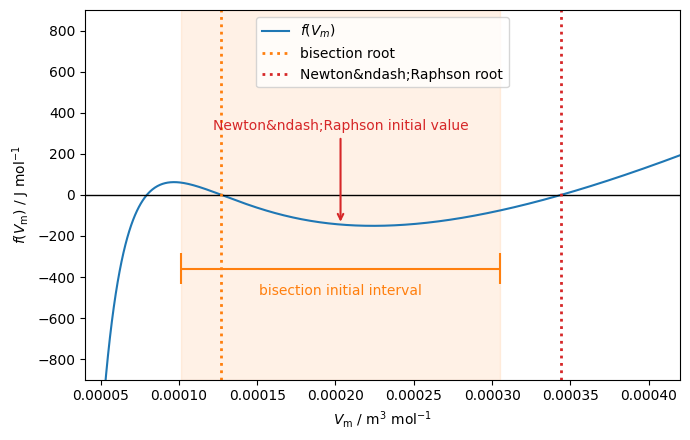

In [6]:
import numpy as np
import matplotlib.pyplot as plt

v_left = 0.2 * v_ideal
v_right = 0.6 * v_ideal
v_nr_guess = 0.4 * v_ideal

v_plot = np.linspace(4.0e-5, 4.5e-4, 1000)
f_plot = [vdw_residual(v_m) for v_m in v_plot]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(v_plot, f_plot, color='tab:blue', label=r'$f(V_m)$')
ax.axhline(0.0, color='black', linewidth=1)
ax.axvspan(v_left, v_right, color='tab:orange', alpha=0.10)
ax.axvline(root_bisection, color='tab:orange', linestyle=':', linewidth=2,
           label='bisection root')
ax.axvline(root_nr, color='tab:red', linestyle=':', linewidth=2,
           label='Newton&ndash;Raphson root')

y_bracket = -360
cap_height = 150
ax.hlines(y_bracket, v_left, v_right, color='tab:orange', linewidth=1.5)
ax.vlines(
    [v_left, v_right],
    y_bracket - 0.5 * cap_height,
    y_bracket + 0.5 * cap_height,
    color='tab:orange',
    linewidth=1.5,
)
ax.text(
    0.5 * (v_left + v_right), -435, 'bisection initial interval',
    color='tab:orange', ha='center', va='top',
)

ax.annotate(
    'Newton&ndash;Raphson initial value',
    xy=(v_nr_guess, vdw_residual(v_nr_guess)),
    xytext=(v_nr_guess, 300),
    ha='center', va='bottom',
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1.5),
    color='tab:red',
)

ax.set_xlabel(r'$V_{\mathrm{m}}$ / m$^3$ mol$^{-1}$')
ax.set_ylabel(r'$f(V_{\mathrm{m}})$ / J mol$^{-1}$')
ax.set_xlim(4.0e-5, 4.2e-4)
ax.set_ylim(-900, 900)
ax.legend(loc='upper center')
fig.tight_layout()


For bisection, the convergence behaviour is easy to read off from the graph:
our initial interval brackets the middle root, hence the method converges to it. 
For Newton&ndash;Raphson, the situation is more subtle. Although the initial guess is 
closer to the middle root, it converges to the rightmost root. 
In general, the convergence of Newton&ndash;Raphson can be surprisingly complicated.
Interested readers may look at the idea of a [*Newton fractal*](wiki:Newton_fractal),
which visualises how strongly the method can depend on the initial guess.

## Self-Study Questions

1. Why does the bisection method require an interval that brackets a root?
2. What is meant by iteration, and how is it represented in the two
   implementations above?
3. Play around with the initial guesses and observe how the convergence behaviour changes. 
   Find guesses that lead to the leftmost root for both methods.